# **Deliverable 1: Radiation Physics and Image Quality**

---

## Overview

This deliverable covers foundational and advanced concepts from **Weeks 2-5** (Lectures 1-12) of the course. You will explore:
1. Radiation physics and ionizing radiation
2. X-ray production and energy scales
3. Photon-matter interactions (photoelectric, Compton, attenuation)
4. Spatial resolution and system blurring
5. Linear systems, MTF, and image sharpness
6. Noise sources, SNR, and image quality
7. Quantum noise, dose optimization, and trade-offs
8. Comprehensive design challenge for imaging protocols

You will engage with the material through a combination of conceptual questions and guided coding exercises designed to strengthen physical intuition and practical problem-solving skills. By the end of this deliverable, you will be able to interpret imaging trade-offs, analyze image quality metrics, and make informed decisions when optimizing imaging protocols for clinical applications.

---
## **<u>Part 1: Radiation Physics</u>**

### 1.1 Ionizing Radiation Classification and Energy Scales

**Key Concept:**
Radiation is classified by whether it has enough energy to knock electrons out of atoms (ionization). This happens when the photon energy exceeds the **ionization potential** of an atom (~13.6 eV for hydrogen).

**Energy Classification:**
- **Non-ionizing:** Visible light (1.6-3.1 eV), radio waves (<0.00001 eV)
  - Energy too low to ionize atoms
  - Cannot damage DNA directly
  
- **Ionizing:** X-rays (keV range), gamma rays (keV-MeV range)
  - High enough energy to remove electrons from atoms
  - Can damage living tissue and DNA
  - Used in medical imaging (controlled exposure)

**Key Equation:**
$$E = h\nu = \frac{hc}{\lambda}$$

- Where: 
    - h = 6.626×10⁻³⁴ J·s (Planck's constant)
    - c = 3×10⁸ m/s (speed of light)

### **Question 1**

**Scenario:** A patient asks why a chest X-ray is "safe" but they worry about radiation exposure.

Using the concepts above, answer:
- (a) Why is a chest X-ray classified as ionizing radiation? What does "ionizing" mean?

- (b) A chest X-ray delivers ~0.1 mSv. A CT scan delivers ~7 mSv (70× higher). What does this mean for radiation dose to the patient?

**(a)** A chest X-ray is classified as an ionizing radiation because it has radition with enough energy than can ionize matter. Energy with greater than 12-15 eV can ionize matter, x-ray photons produce 20-140 keV. Ionization refers to the removal of an electron from an atom, creating an ion pair. 

**(b)** A CT scan delivers ~70 times more radiation energy into the patient. A higher radiation dose means higher stochastic risk like cancer, but CT scans are still justified since the benefit of more detailed diagnosis outweigh the risks. If the patient has issues more serious than bone injuries like organ injuries, then a CT scan is a justified measure.

Extra sources:
- https://www.health.harvard.edu/cancer/radiation-risk-from-medical-imaging
- https://www.hopkinsmedicine.org/health/treatment-tests-and-therapies/ct-vs-mri-vs-xray

### 1.2 X-ray Production

**X-ray Generation:**
X-rays are produced when high-energy electrons strike a metal target (usually tungsten).

**Two Production Mechanisms:**

1. **Bremsstrahlung (Braking Radiation):**
   - Electron decelerates near nucleus
   - Loses kinetic energy → emitted as X-ray photon
   - Produces **continuous spectrum** of energies
   - Maximum energy = tube voltage (kVp)
   - Accounts for ~80% of X-ray output

2. **Characteristic X-rays:**
   - Electron knocks out inner shell electron
   - Outer electron fills vacancy
   - Energy difference emitted as X-ray
   - Produces **discrete spectral lines** (specific energies)
   - Depends on target material (e.g., K-alpha, K-beta lines for tungsten)

**X-ray Spectrum:**
- Shape determined by tube voltage (kVp) and filtration
- Higher kVp → higher maximum energy and intensity
- Filtration removes low-energy photons (patient protection)

**Key Equation:**
$$E_{max} = eV_{peak}$$
- Where:
   - $V_{peak}$ is the peak tube voltage in kV

### **Question 2**

An X-ray tube operates at 100 kVp with a tungsten target.

- a) What is the maximum energy (in keV) of X-ray photons that can be produced?

- b) Explain the difference between bremsstrahlung and characteristic X-rays. Which one produces the continuous spectrum and which produces discrete peaks?

- c) Why do we use filtration (typically aluminum) at the X-ray tube output? What effect does this have on the X-ray spectrum and patient dose?

**(a)** $E_{max}$ = kVp. The maximum energy produced by the X-ray photons is equal to the peak tube voltage, in 100 keV.

**(b)** Bremsstrahlung radiation occurs when a fast electron passes the nucleus and is slowed down by Coulomb force, the kinetic energy that was lost is then converted into photon energy. The photon energy ranges anything from zero up to the energy of the initial electron, hence why bremsstrahlung provides a continuous spectrum of photons. 

Characteristic radiation is produced when an incoming electron knocks out a K-shell electron, an outer electron then drops down to fill the vacancy. The energy released in the transitions is released as an x-ray photon. Since the electrons in the atom have fixed energy levels, characteristic radiation produces discrete energy peaks.

**(c)** Filtration is used to remove useless low-energy photons. Low-energy photons dont add much to image quality but increase unecessary patient dose. Filtration also "hardens" the beam, increasing the average energy of the beam and improves penetration.

Extra source:
- https://radiopaedia.org/articles/filters

---

## **<u>Part 2: Photon Interactions</u>**

### 2.1 Interaction Types

**Key Concept:**
When X-rays pass through tissue, they interact through different mechanisms depending on photon energy and material properties.

**Main Interaction Types:**

1. **Photoelectric Effect** (low energy, high-Z materials)
   - X-ray photon absorbed completely
   - Electron kicked out of atom
   - Useful for imaging (produces signal)
   - Why: Bone (high Z) appears bright

2. **Compton Scattering** (medium-high energy)
   - Photon deflected and loses energy
   - Electron recoils
   - Scattered photons reduce image contrast (noise)
   - Why: Anti-scatter grids are used

Refer to the schematic below:

<p align="center">
  <img src="figures/scatter_effect_example.jpg" width="600">
</p>

This illustrates how Compton-scattered photons reach the detector and reduce image contrast, and how anti-scatter grids selectively absorb these scattered photons while allowing primary radiation to pass.

3. **Pair Production** (very high energy, >1.02 MeV)
   - Rare in medical imaging
   - Not important for X-rays (typically 20-150 keV)

**Attenuation:**
X-rays passing through material follow the **Beer-Lambert Law**:
$$I = I_0 e^{-\mu x}$$

- where:
    - $I$ = transmitted intensity
    - $I_0$ = incident intensity
    - $\mu$ = linear attenuation coefficient (material dependent)
    - $x$ = material thickness

### **Question 3**

Consider an X-ray imaging system operating at 80 keV.

- a) At this energy, both photoelectric absorption and Compton scattering occur. Which interaction mechanism is more likely to dominate in bone tissue versus soft tissue, and why? (Hint: Consider the atomic number dependence)

- b)Explain why Compton scattered photons are problematic for image quality. What specific image quality metric do they degrade?

- c) X-ray imaging systems use anti-scatter grids to reduce the detection of scattered photons. If a grid removes 80% of scattered photons but also blocks 20% of primary (unscattered) photons, when would you choose to use the grid versus imaging without it? Consider both image quality and patient dose.

- d) In CT imaging, we use higher energies (120-140 keV) compared to conventional radiography (60-80 keV). Based on the energy dependence of photoelectric and Compton interactions, how does this affect the contrast between bone and soft tissue in CT images?

**(a)** Photoelectric effect has a higher dependance to the atomic number (Z) of the material, the probability of its interaction is proportional to $\frac{Z^4}{E^3}$. It's more likely to occur in bone tissue because it consists of calcium, which has a high Z value. Soft tissue has lower Z value because it mainly consists of elements like carbon, hydrogen and nitrogen. Compton scattering is dependent on electron density and not Z, and since soft tissue has a lower Z value, the probability of the photoelectric effect is reduced, making compton scattering the dominant interaction.

**(b)** Compton scattered photons change direction when they interact with the tissue, different from the path of the original beam. This produces a low energy "fog" to the image and reduces the contrast between structures.

**(c)** Using a grid removes most scattered photons and produces higher image contrast. But since it also blocks primary photons, the patient may require a higher X-ray dose. A grid should be used when examining thicker body parts where scattering is significant like the chest or the abdomen. Thinner body parts like the hands can skip the grid so it avoids unecessary dosage increase.

**(d)** Photoelectric effect is dominant at lower energies and strongly dependent in higher Z values. At higher energies, the photoelectric effect has lower chance of occuring making compton scattering more dominant. Since contrast primarily comes from the photoelectric effect, using higher energies in CT reduces contrast between bone and soft tissue.

Extra sources:
- https://www.sciencedirect.com/topics/medicine-and-dentistry/compton-scattering
- https://kaimaging.com/do-i-need-an-x-ray-grid/

### 2.2 Beer-Lambert Law & Attenuation

**Attenuation** describes how X-ray intensity decreases as it passes through material.

**Beer-Lambert Law:**
$$I = I_0 e^{-\mu x}$$

- Where:
    - $I$ = transmitted intensity
    - $I_0$ = incident intensity  
    - $\mu$ = linear attenuation coefficient (cm⁻¹) - material dependent
    - $x$ = material thickness (cm)

**Half-Value Layer (HVL):**
- Thickness of material that reduces intensity to 50%
- Related to attenuation coefficient: $HVL = \frac{\ln(2)}{\mu} = \frac{0.693}{\mu}$
- Lower HVL = more attenuation (denser material or lower energy)

**Key Insight:**
- Bone has higher μ than soft tissue → more attenuation → appears bright
- Different energies attenuate differently (energy dependence)
- HVL is a practical measure used in X-ray quality control

### **Question 4**

A 60 keV X-ray beam passes through soft tissue with linear attenuation coefficient μ = 0.2 cm⁻¹.

- a) If the incident intensity is $I_0 = 10,000$ photons, what is the transmitted intensity after passing through 5 cm of tissue? Use the Beer-Lambert law.

- b) Calculate the Half-Value Layer (HVL) for this tissue at 60 keV.

- c) If you increase the X-ray energy from 60 keV to 120 keV, the attenuation coefficient decreases to μ = 0.15 cm⁻¹. What happens to the transmitted intensity through the same 5 cm of tissue? Calculate the new transmitted intensity and explain why higher energy X-rays penetrate better.

**(a)** $$I = I_0 e^{-\mu x} = 10000 e^{-0.2 * 5} = 3678.7944... \approx 3679 \: photons$$ 

**(b)** $$HVL = \frac{\ln(2)}{\mu} = \frac{0.693}{0.2} \approx 3.466 \: cm $$

**(c)** $$I = I_0 e^{-\mu x} = 10000 e^{-0.15 * 5} = 4723.666... \approx 4724 \: photons$$ 

At higher energies, the attenuation coefficient is lower meaning that the the probability of an X-ray interacting per unit distance is reduced. Which is why x-rays penetrate better at higher energies.

---

## **<u>Part 3: Spatial Resolution</u>**

### 3.1 Point Spread Function (PSF) and System Blurring

**Key Concept:**

Real imaging systems are **imperfect**. A point source (infinitely small object) doesn't appear as a point in the image—it appears as a **blurred blob**. This blurring limits how small an object you can see.

**Point Spread Function (PSF):**
- **PSF** = How much a point source gets blurred by the imaging system
- **Shape:** Usually Gaussian-like (bell curve)
- **Width:** Characterized by **FWHM** (Full Width at Half Maximum)
  - Smaller FWHM = sharper system (better resolution)
  - Larger FWHM = blurrier system (worse resolution)


**Resolution Rule of Thumb:** You can distinguish two objects only if they're separated by at least the **FWHM of the PSF**. Anything closer just blurs together.

**Image Formation:**

$$\text{Blurred Image} = \text{Sharp Object} \otimes \text{PSF}$$

  - The $\otimes$ symbol means "convolved with"—every sharp point gets replaced by a blurred copy (PSF shape).

**Real Example - Chest X-ray:**
- System resolution: ~0.2 mm FWHM
- Lung nodule: 3-4 mm → **Visible** (15-20× larger than PSF)
- Micro-calcification: 1-3 mm → **Borderline** (5-15× larger)
- Small vessel: 0.5 mm → **Invisible** (blurs away)

### **Question 5**

You're designing an X-ray detector system for mammography, where high resolution is critical to detect small microcalcifications (~100 μm).

- a) If your current detector has a PSF with FWHM = 200 μm, can you reliably detect 100 μm objects? Explain your reasoning using the relationship between FWHM and object size.

- b) You have two detector options:
   - **Detector A**: 50 μm pixels, FWHM = 100 μm, readout time = 5 seconds
   - **Detector B**: 100 μm pixels, FWHM = 200 μm, readout time = 1 second
   
   Which detector would you choose for mammography and why? Consider resolution requirements, patient motion, and clinical workflow.

- c) In PET imaging, using smaller detector crystals improves spatial resolution but also increases system cost and complexity. If you could reduce FWHM from 5 mm to 2.5 mm (2× improvement) at a 3× increase in cost, what clinical applications would justify this investment? Name at least two specific imaging tasks where the improved resolution would significantly impact diagnosis.

**(a)** No, a 100 μm object would not be reliably detected because it is smaller than the PSF FWHM.

**(b)** I would choose detector A. Based on the FWHM, dectector A would have a smaller blur and can show details more clearly. Even though it has a longer readout time, when it comes to mammography, image quality is more important than speed when trying to detect breast cancer early. 

**(c)** I would say that a higher resolution PET scanner is a worthy investment because you could perform...
- 1. Higher Resolution Quantitive Neuroimaging compared to current clinical PET scanners.
- 2. Small animal and research PET to use for animal studies like imaging for rats to research into cancer, neuroscience, medicine, etc.

Extra sources:
- https://aapm.onlinelibrary.wiley.com/doi/10.1002/mp.16223
- https://academic.oup.com/ilarjournal/article/49/1/54/778523

### 3.2 Linear Systems Theory & MTF

**Linear Systems Theory:**
Medical imaging systems can be modeled as linear, shift-invariant systems.

**Key Properties:**
1. **Linearity:** If input doubles, output doubles
2. **Shift Invariance:** System response doesn't depend on position
3. **Convolution:** Image formation is described by convolution with PSF
   $$\text{Image} = \text{Object} \otimes \text{PSF}$$

**Modulation Transfer Function (MTF):**
- MTF is the **Fourier transform of the PSF**
- Measures how well the system reproduces different spatial frequencies
- MTF ranges from 0 (no reproduction) to 1 (perfect reproduction)
- **Spatial frequency** measured in cycles/mm or line pairs/mm

**Interpreting MTF:**
- MTF = 1.0 at low frequencies → large objects reproduced perfectly
- MTF decreases at high frequencies → fine details are blurred
- **MTF at 50%** (where MTF = 0.5) is often used as resolution metric
- Related to FWHM: Better resolution → higher MTF at high frequencies

**Example:**
- System A: MTF = 0.5 at 5 cycles/mm → can resolve 0.1 mm details
- System B: MTF = 0.5 at 10 cycles/mm → better, can resolve 0.05 mm details

### **Question 6**

You are comparing two X-ray detector systems:

| System | MTF at 2 cycles/mm | MTF at 5 cycles/mm | MTF at 10 cycles/mm |
|--------|-------------------|-------------------|---------------------|
| System A | 0.95 | 0.70 | 0.30 |
| System B | 0.90 | 0.50 | 0.10 |

- a) Which system has better spatial resolution? Explain your reasoning using the MTF values.

- b) For detecting a 1 mm lesion (which contains frequencies around 1-2 cycles/mm), which system would be more suitable?

- c) Explain the relationship between MTF and PSF. How are they related mathematically, and what does each tell us about the imaging system?


**(a)** System A has better spatial resolution because it has higher MTF values, especially at higher frequencies. MTF is a measure of how much contrast survives at each spatial frequency, and compared to System B, System A has higher values meaning better contrast all around.

**(b)** Comparing the MTF values at 2 cycles/mm, System A has a greater value of 0.95 than System B with a value of 0.90, meaning System A has slightly better contrast. System A would be more suitable.

**(c)** PSF is the system's response to a single point and shows blurring in an image. MTF is the fourier transform of PSF, and tells us how much contrast survives at different spatial frequencies. A wider PSF shows more blur, and leads to lower MTF values and worse resolution. A narrower PSF shows less blur and produces higher MTF values and better resolution.

Extra Source:
- https://www.microscopyu.com/microscopy-basics/modulation-transfer-function

---

## **<u>Part 4: Noise & Image Quality</u>**

### 4.1 Understanding Image Noise

**Quantum (Poisson) Noise** is the primary noise source in X-ray and nuclear imaging:

- Arises from the random nature of photon emission and detection
- Follows **Poisson statistics**: if we detect N photons on average, the noise (standard deviation) is $\sigma = \sqrt{N}$
- **Signal-to-Noise Ratio (SNR)**: $SNR = \frac{N}{\sigma} = \frac{N}{\sqrt{N}} = \sqrt{N}$

**Key insights:**
- SNR increases with the square root of photon count
- To double SNR, you need 4× more photons (4× more dose)
- **Rose Criterion**: Objects are detectable when SNR ≥ 5

**Noise reduction strategies:**
1. Increase photon count (higher dose)
2. Spatial averaging (smoothing filters)
3. Temporal averaging (multiple acquisitions)

Below is an example of a noisy MRI image:

<p align="center">
  <img src="figures/MRI_Highnoise.jpg" width="400">
</p>

### **Coding Exercise 1**

In this exercise, you will implement and compare two different denoising filters:
1. **Gaussian filter** - Simple smoothing
2. **Median filter** - Edge-preserving, good for impulse noise

Your task is to:
- Implement both filters with appropriate parameters
- Calculate the Peak Signal-to-Noise Ratio (PSNR) for each filtered image
- **Choose the best filter** for this medical image and justify your choice

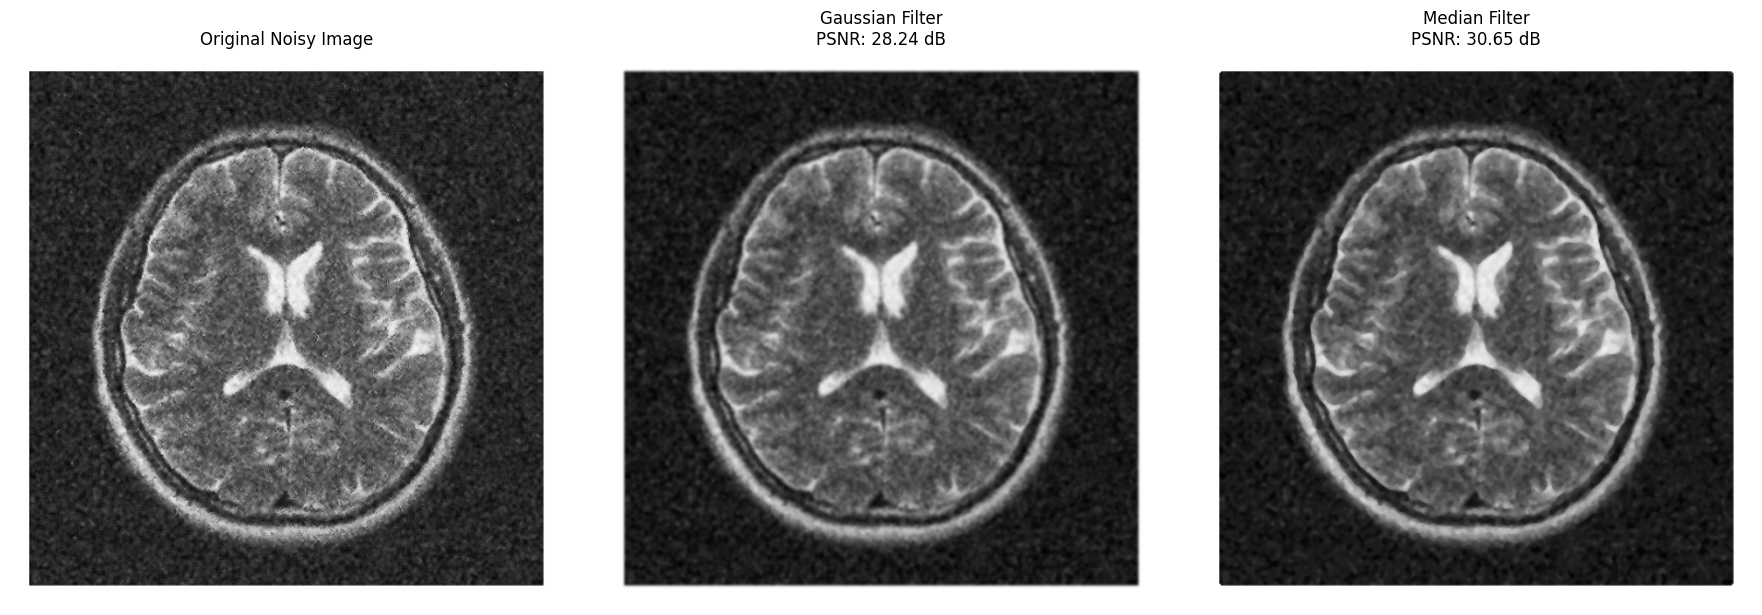

In [135]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter, median_filter

# Load the noisy MRI image
img = Image.open('figures/MRI_Highnoise.jpg').convert('L')  # Convert to grayscale
img_array = np.array(img, dtype=float)

# Implement both different filters
    # Hint: Try different parameter values to optimize each filter

sigma = 1.3              # TODO: choose sigma
kernel_size = 5            # TODO: choose median size (odd integer)

# 1. Gaussian filter (adjust sigma)
img_gaussian = gaussian_filter(img_array, sigma=sigma)  # TODO: Optimize sigma

# 2. Median filter (adjust size)
img_median = median_filter(img_array, size=kernel_size)  # TODO: Optimize size

# Calculate PSNR for each filtered image
def calculate_psnr(original, filtered):
    """
    Calculate Peak Signal-to-Noise Ratio
    PSNR = 10 * log10(MAX^2 / MSE)
    where MSE is the mean squared error
    """
    # Implement PSNR calculation
        # Hint: For images, MAX is typically 255 for 8-bit images
    
    # Find Mean Squared Error
    mse = np.mean(np.square(original - filtered)) # TODO
    
    # If MSE is 0, then that means no noise is present in the signal
    if (mse == 0):
        return 100.0
    
    # Use max value for 8-bit representation
    max_pixel = 255.0  # TODO
    
    # Calculate PSNR
    psnr = 10 * np.log10(np.square(max_pixel) / mse)      # TODO
    return psnr

# Calculate PSNR for a reference (you'll need to think about what reference to use)
# For demonstration, we'll calculate PSNR relative to the original noisy image
# In practice, you'd want a ground truth clean image

# Display results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_array, cmap='gray')
axes[0].set_title('Original Noisy Image')
axes[0].axis('off')

axes[1].imshow(img_gaussian, cmap='gray')
axes[1].set_title(f'Gaussian Filter\nPSNR: {calculate_psnr(img_array, img_gaussian):.2f} dB')
axes[1].axis('off')

axes[2].imshow(img_median, cmap='gray')
axes[2].set_title(f'Median Filter\nPSNR: {calculate_psnr(img_array, img_median):.2f} dB')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Your Analysis:

- a) Which filter did you choose and why?

**(a)** I chose the gaussian filter. While the result appears slightly more grainy, it preserves details and is more consistent with the original photo. The median filter removes more noise but also blurs details, smudging edges and textures.

For the gaussian filter, I chose a sigma of 1.3 which produced a PSNR of 28.24, a good balance between noise reduction and detail clarity. For the median filter, I chose a kernel of 5x5 and it produced a PSNR of 30.65, going lower to 3x3 barely removed any noise and going to 7x7 made the image too blurry. Even though the median filter had a higher PSNR, I prefer the gaussian filter because it maintained finer details better.

Extra Sources:
- https://www.ni.com/en/shop/data-acquisition-and-control/add-ons-for-data-acquisition-and-control/what-is-vision-development-module/peak-signal-to-noise-ratio-as-an-image-quality-metric.html
- https://medium.com/jun94-devpblog/cv-2-gaussian-and-median-filter-separable-2d-filter-2d11ee022c66
- https://www.geeksforgeeks.org/python/python-peak-signal-to-noise-ratio-psnr/


### 4.2 Detective Quantum Efficiency (DQE)

**DQE** measures how efficiently an imaging system uses the incoming radiation to produce image information.

**Definition:**
$$DQE = \frac{SNR_{out}^2}{SNR_{in}^2}$$

Where:
- $SNR_{out}$ = signal-to-noise ratio in the output image
- $SNR_{in}$ = signal-to-noise ratio in the input radiation

**Key Concepts:**
- DQE ranges from 0 to 1 (or 0% to 100%)
- **Perfect detector:** DQE = 1 (no noise added by detector)
- **Real detectors:** DQE < 1 (detector adds noise)
- Higher DQE = better detector (more efficient use of radiation)

**Practical Implications:**
- High DQE detector → need less radiation dose for same image quality
- DQE depends on spatial frequency (usually decreases at high frequencies)
- DQE depends on exposure level (often highest at moderate exposures)

**Example:**
- Film/screen: DQE ≈ 0.3-0.4 (30-40%)
- Digital radiography (DR): DQE ≈ 0.6-0.7 (60-70%)
- DR systems allow lower dose for same image quality

### **Question 7**

Two X-ray detector systems are being compared:

- **System A (Film/Screen):** DQE = 0.35, cost = $10,000
- **System B (Digital DR):** DQE = 0.70, cost = $50,000

Both systems receive the same input radiation with $SNR_{in} = 100$.

- a) Calculate the output SNR for each system.

- b) If you want to achieve the same output SNR with System A as System B naturally produces, by what factor would you need to increase the radiation dose to System A?

- c) In a high-volume clinical setting performing 100 chest X-rays per day, discuss whether the higher cost of System B is justified. Consider patient dose, image quality, and long-term patient safety.

**(a)**
$$DQE = \frac{SNR_{out}^2}{SNR_{in}^2} \Longrightarrow SNR_{out} = {SNR_{in}} \cdot {\sqrt{DQE}}$$
$$\text{System A:} \quad SNR_{out} = {100} \cdot {\sqrt{0.35}} \approx 59.16 $$
$$\text{System B:} \quad SNR_{out} = {100} \cdot {\sqrt{0.70}} \approx 83.67 $$

**(b)**  
$$\text{Dose Ratio} = \frac{DQE_{new}}{DQE_{old}} = \frac{0.7}{0.35} = 2$$
$$\text{In order to reach the same output SNR as System B, System A must increase its radiation dose by a factor of 2.}$$


**(c)** I would say that System B is a worthy investment for a few reasons. My first reasoning is that System B has a higher DQE which means that it produces higher-quality images effectively, System B has a 70% efficiency while System A only has 35%. Second, System B is also better for long-term patient safety because it requires only half the dosage to reach the same SNR as System A would. Lower dosage means less cumulative radiation risk for the patient.

---

## **<u>Part 5: Quantum Noise & Dose Analysis</u>**

### **Coding Exercise 2**

In this exercise, simulate the effect of photon counting statistics on image quality. You will:
- Generate a simple "phantom" image
- Add Poisson noise at different dose levels
- Calculate SNR as a function of photon count
- Verify the theoretical relationship: $SNR = \sqrt{N}$

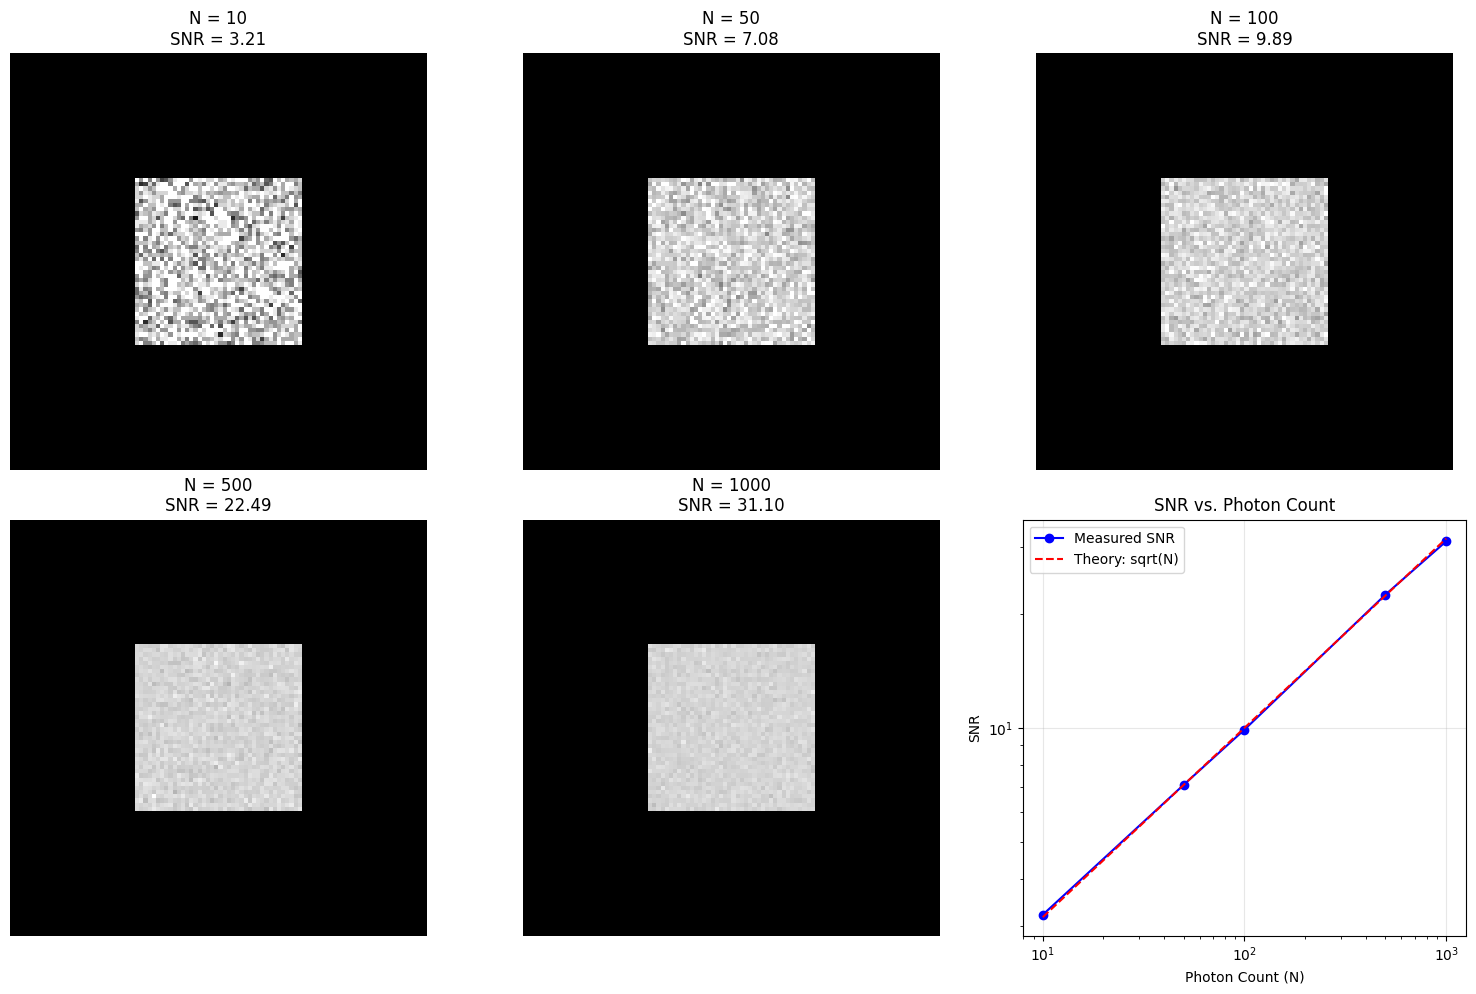


Dose levels and corresponding SNR:
N =   10 photons: SNR = 3.21 (Theory: 3.16)
N =   50 photons: SNR = 7.08 (Theory: 7.07)
N =  100 photons: SNR = 9.89 (Theory: 10.00)
N =  500 photons: SNR = 22.49 (Theory: 22.36)
N = 1000 photons: SNR = 31.10 (Theory: 31.62)


In [136]:
import numpy as np
import matplotlib.pyplot as plt

# Create a simple phantom (uniform square in background)
phantom = np.zeros((100, 100))
phantom[30:70, 30:70] = 1.0  # Square with intensity 1.0

# Define different photon dose levels (mean photons per pixel)
dose_levels = [10, 50, 100, 500, 1000]
snr_measured = []

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, N_photons in enumerate(dose_levels):
    
    # Generate Poisson noise
        # Hint: Scale phantom by N_photons, apply Poisson noise, then normalize back
    
    # TODO
    scaled_phantom = phantom * N_photons                    # Scale phantom
    poisson_noise = np.random.poisson(scaled_phantom)       # Apply Poisson noise
    noisy_phantom = poisson_noise / N_photons               # Normalize back back
    
    # Calculate SNR in the central square region
    signal_region = noisy_phantom[30:70, 30:70]
    background_region = noisy_phantom[0:20, 0:20]
    
    signal_mean = np.mean(signal_region)        # TODO
    background_mean = np.mean(background_region)        # TODO
    noise_std = np.std(signal_region)        # TODO
    
    snr = (signal_mean - background_mean) / (noise_std)       # TODO
    snr_measured.append(snr)
    
    # Display noisy phantom
    axes[idx].imshow(noisy_phantom, cmap='gray', vmin=0, vmax=1.2)
    axes[idx].set_title(f'N = {N_photons}\nSNR = {snr:.2f}')
    axes[idx].axis('off')

# Plot SNR vs. N (log-log scale)
axes[5].loglog(dose_levels, snr_measured, 'bo-', label='Measured SNR')

# Plot theoretical SNR = sqrt(N) for comparison
theoretical_snr = np.sqrt(dose_levels)        # TODO
axes[5].loglog(dose_levels, theoretical_snr, 'r--', label='Theory: sqrt(N)')
axes[5].set_xlabel('Photon Count (N)')
axes[5].set_ylabel('SNR')
axes[5].set_title('SNR vs. Photon Count')
axes[5].legend()
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDose levels and corresponding SNR:")
for N, snr in zip(dose_levels, snr_measured):
    print(f"N = {N:4d} photons: SNR = {snr:.2f} (Theory: {np.sqrt(N):.2f})")

Your Analysis:

- a) Do your measurements agree with the theoretical prediction? If there are differences, what might explain them?

**(a)** Yes, my measurements agree with the theoretical prediction that... $$SNR = \sqrt{N}$$

At each dose level, you can see that the measured SNR is very close to the theoretical SNR value. The differences are most likely due to the randomness in the poisson distribution where the number of photons detected vary from run to run. We are also only running a single trial of the SNR calculation per dose, generating the SNR multiple times and taking its average might show more consistent values. 


### **Coding Exercise 3**

You're tasked with determining the minimum radiation dose needed for three different clinical scenarios:

1. **Routine chest X-ray** - Need to detect 5 mm nodules (require SNR ≥ 5)
2. **Diagnostic CT** - Need to detect 2 mm lesions (require SNR ≥ 8)
3. **High-risk screening** - Need to detect 1 mm microcalcifications (require SNR ≥ 10)

Given that your baseline protocol delivers N₀ = 1000 photons and achieves SNR₀ = 10 for a 5 mm object:

**Calculate:**
- a) Required photon count for each scenario

- b) Relative dose compared to baseline

In [137]:
# Baseline values
N0 = 1000  # photons
SNR0 = 10  # for 5 mm object

# Calculate required photon counts for each scenario
    # Hint: Use SNR = sqrt(N) and scale appropriately

scenarios = [
    {'name': 'Routine Chest X-ray', 'size_mm': 5, 'required_snr': 5},
    {'name': 'Diagnostic CT', 'size_mm': 2, 'required_snr': 8},
    {'name': 'High-risk Screening', 'size_mm': 1, 'required_snr': 10}
]

print("Dose Optimization Results:")
print("=" * 70)

for scenario in scenarios:
    # Calculate required N and relative dose
    # Consider both SNR requirements and object size
    
    # SNR = sqrt(N) -> N = SNR^2
    # Scaling photon count for size based on SNR of 5mm object
    # SNR/SNR0 = sqrt(N/N0) * (size/5)
    # N = N0 * (SNR/SNR0)^2 (5/size)^2
    
    required_snr = scenario["required_snr"]
    size_mm = scenario["size_mm"]
    
    required_N = N0 * ((required_snr / SNR0)**2) * ((5 / size_mm)**2)       # TODO
    
    # Compare relative dose to baseline value
    relative_dose = required_N / N0                                         # TODO
    
    print(f"\n{scenario['name']}:")
    print(f"  Object size: {scenario['size_mm']} mm")
    print(f"  Required SNR: {scenario['required_snr']}")
    print(f"  Required photons: {required_N:.0f}")
    print(f"  Relative dose: {relative_dose:.2f}x baseline")

Dose Optimization Results:

Routine Chest X-ray:
  Object size: 5 mm
  Required SNR: 5
  Required photons: 250
  Relative dose: 0.25x baseline

Diagnostic CT:
  Object size: 2 mm
  Required SNR: 8
  Required photons: 4000
  Relative dose: 4.00x baseline

High-risk Screening:
  Object size: 1 mm
  Required SNR: 10
  Required photons: 25000
  Relative dose: 25.00x baseline


### **Coding Exercise 4**

Create a 2D analysis showing how image quality metrics vary with both radiation dose and detector pixel size.

You will create a heatmap showing the "detectability index" (combining SNR and resolution) as a function of:
- X-axis: Radiation dose (relative to baseline)
- Y-axis: Detector pixel size

This helps visualize the complex trade-offs in imaging system design.

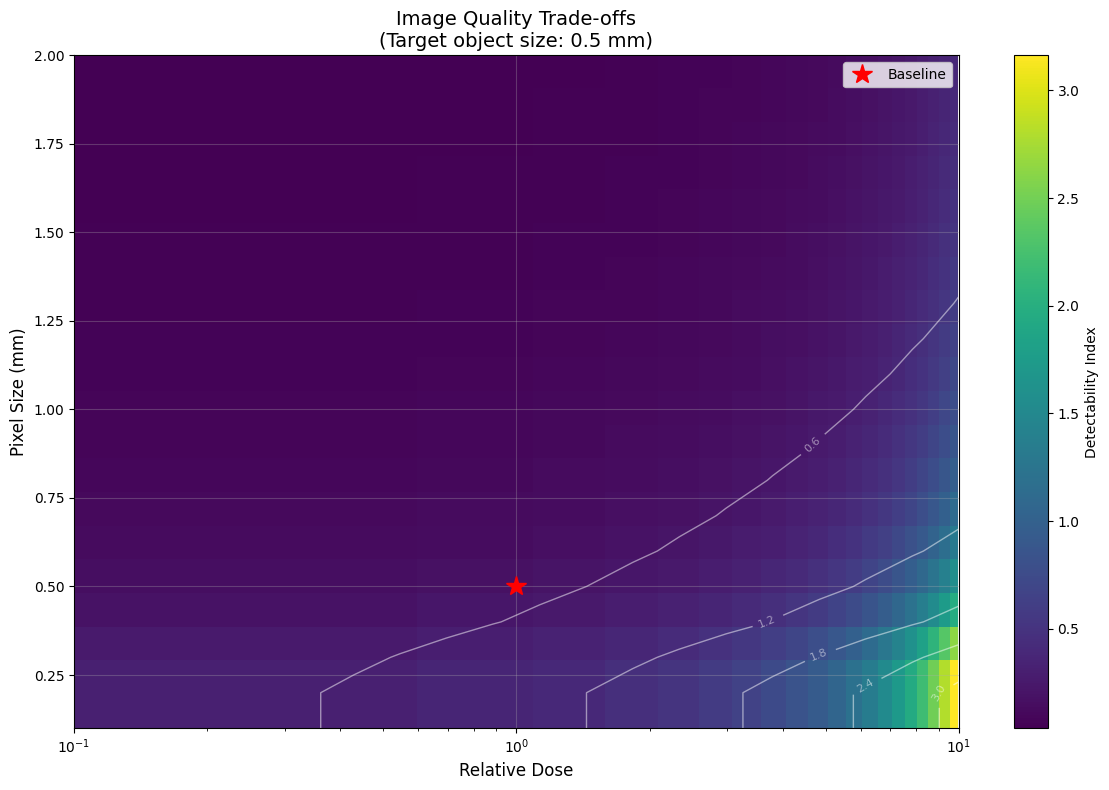

In [138]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameter ranges
dose_range = np.logspace(-1, 1, 20)  # 0.1x to 10x baseline dose
pixel_size_range = np.linspace(0.1, 2.0, 20)  # 0.1 to 2.0 mm pixels

# Target object size (mm)
target_size = 0.5  # mm

# Calculate detectability index for each combination
# Detectability ∝ SNR × (resolution_factor)
# where resolution_factor decreases as pixel_size approaches target_size

# Make a matrix of number of pixels by number of doses
detectability = np.zeros((len(pixel_size_range), len(dose_range)))       # TODO

for i, pixel_size in enumerate(pixel_size_range):
    for j, dose in enumerate(dose_range):
        # Calculate detectability
        # SNR component from dose
        snr_component = np.sqrt(dose)        # TODO
        
        # Resolution component (decreases as pixel size increases)
        # Simple model: can't detect objects smaller than ~2× pixel size
        if pixel_size < target_size / 2:
            resolution_component = 1.0
        else:
            # Normalize by two pixels
            resolution_component = target_size / (2 * pixel_size)        # TODO
        
        detectability[i, j] = snr_component * resolution_component

# Create heatmap
plt.figure(figsize=(12, 8))
plt.imshow(detectability, aspect='auto', origin='lower', cmap='viridis',
           extent=[dose_range[0], dose_range[-1], pixel_size_range[0], pixel_size_range[-1]])
plt.colorbar(label='Detectability Index')
plt.xlabel('Relative Dose', fontsize=12)
plt.ylabel('Pixel Size (mm)', fontsize=12)
plt.title(f'Image Quality Trade-offs\n(Target object size: {target_size} mm)', fontsize=14)
plt.xscale('log')

# Add contour lines
contours = plt.contour(dose_range, pixel_size_range, detectability, 
                       levels=5, colors='white', alpha=0.5, linewidths=1)
plt.clabel(contours, inline=True, fontsize=8)

# Mark some interesting operating points
plt.plot([1.0], [0.5], 'r*', markersize=15, label='Baseline')
plt.legend(fontsize=10)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Your Analysis:

Based on the heatmap:

- a) What's the optimal operating point for detecting 0.5 mm objects?

- b) If you had to reduce dose by 50%, how should you adjust pixel size to maintain detectability?

- c) What does this tell you about the practical limits of low-dose imaging?

**(a)** Based on the heatmap, the yellow/green region on the bottom right has the highest detectability. Detectability increases as you increase relative dosage and decrease pixel size. The optimal point in this case would be with a pixel size of less than or equal to 0.25mm with a dosage higher than baseline.

**(b)** To maintain detectability while cutting dose in half, you should lower the pixel size.

**(c)** The heatmap shows that at low doses, detectability is poor no matter the pixel size. At very low dosage, the image is dominated by noise and objects cannot be detected even with smaller pixels.

---

## **<u>Part 6: Comprehensive Design Challenge</u>**

You are designing an imaging protocol for lung cancer screening. The goal is to detect 3 mm nodules in the lung parenchyma.

**System constraints:**
- Maximum allowable dose: 3 mSv (effective dose)
- Available detector pixel sizes: 0.5 mm, 1.0 mm, 1.5 mm
- Required detection SNR: 6 (based on Rose criterion with safety factor)

### **Question 8**

- a) Choose a detector pixel size and justify your choice based on the spatial resolution requirements for detecting 3 mm nodules.

- b) Calculate the minimum photon count needed to achieve SNR = 6, assuming baseline noise characteristics.

- c) If Compton scatter contributes 40% of detected photons, how does this affect your SNR calculation? Would you use an anti-scatter grid?

- d) Estimate whether your protocol meets the 3 mSv dose constraint. If not, what compromises would you make and why?

**(a)** We collect 2 pixels at 1.5mm, 3 at 1.0mm, and 6 at 0.5mm. Smaller pixels can provide better resolution, but each pixel is more sensitive to noise which can degrade contrast. In this case I would choose 1.0mm pixels as it provides a good balance between resolution and noise.

**(b)** Based on the baseline characteristics from Coding Exercise 3 with SNR0 = 10 & N0 = 1000

$$\frac{SNR}{SNR_{0}} = \sqrt{\frac{N}{N_{0}}} \Longrightarrow \frac{SNR^2}{SNR_{0}^2} = \frac{N}{N_{0}} \Longrightarrow N = {N_{0}} \cdot \frac{SNR^2}{SNR_{0}^2} = 1000 \cdot \frac{6^2}{10^2} = 360 \: \text{photons}$$


**(c)** We need 360 useful photons for imaging. If 40% of total photons were from compton scattering, then 360 photons is 60% of the total photons we should aim for. 

$$N_{total} = \frac{N_{useful}}{0.6} = \frac{360}{0.6} = 600 \: \text{photons}$$

With 40% scattering, we would need to detect around 600 photons in order to get the same quality of imaging. In this case I would use an anti-scatter grid.

**(d)** Assuming that dose is proportional to photon count, I first find the relative dose and multiply it by the 3 mSv limit.

$$\text{Relative Dose} = \frac{N}{N_{0}} = \frac{360}{1000} = 0.36 \Longrightarrow 0.36 \cdot 3 \: mSv = 1.08 \: mSv$$

With compton scattering:

$$\text{Relative Dose} = \frac{600}{1000} = 0.6 \Longrightarrow 0.6 \cdot 3 \: mSv = 1.8 \: mSv$$

We can see that in both cases, the dose is well below the constraint. If the dose exceeded the constraint then I would have increased the pixel size or reduce scattering more efficiently to lower the patient's required dose.


Extra source:
- https://www.tucsen.com/learning/why-pixel-size-matters-in-light-collection-for-microscopy/

---
## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. All cells must be executed in order.

2. **PDF Export** (`.pdf`): Export your notebook to PDF (File → Export as PDF, or print to PDF). Verify all figures and equations render correctly.

**Important:** All answers must be completed directly in this Jupyter notebook.

**File naming convention:** `LastName_FirstName_Deliverable1.ipynb` and `.pdf`

**Due:** Monday, February 9, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Analysis Due |
|---------|------------------------|
| **Part 1: Radiation Physics** | Q1 (a,b), Q2 (a,b,c) |
| **Part 2: Photon Interactions** | Q3 (a,b,c,d), Q4 (a,b,c) |
| **Part 3: Spatial Resolution** | Q5 (a,b,c), Q6 (a,b,c) |
| **Part 4: Noise & Image Quality** | Coding Exercise 1 + Analysis, Q7 (a,b,c) |
| **Part 5: Quantum Noise & Dose Analysis** | Coding Exercise 2 + Analysis, Coding Exercise 3, Coding Exercise 4 + Analysis |
| **Part 6: Comprehensive Design Challenge** | Q8 (a,b,c,d) |